# Project Demo (Jack Mulvihill's Half)

## Imported Libraries

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pypq
import textwrap 

# For Apriori (Frequent Pattern Mining)
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# For counting and filtering frequent item pairs
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)

# ---------------------------------------------------------
# 📂 GLOBAL PATHS - DO NOT CHANGE THESE
# ---------------------------------------------------------
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"
CSV_PATH = BASE_PATH / "csv-files" / "may-2025"

print(f"✅ Data Directories Set:\n  - Parquet: {PARQUET_PATH}\n  - CSV: {CSV_PATH}")

# Focusing on works published within the past five years
MIN_YEAR = 2020
MAX_YEAR = 2025

# Exclude works with low or no citations
MIN_CITS = 10

✅ Data Directories Set:
  - Parquet: /data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025
  - CSV: /data/shared/OpenAlex/processed-snapshots/csv-files/may-2025


## Peek Parquet (Inspects File Schemas)

In [2]:
def peek_parquet(path):
    """
    peeks at a parquet file (or a directory containing parquet files) without reading the whole thing and prints the following:
    * Path
    * schema
    * number of pieces (fragments)
    * number of rows 
    """
    path = Path(path)
    parq_file = pypq.ParquetDataset(path)
    piece_count = len(parq_file.fragments)
    schema = textwrap.indent(parq_file.schema.to_string(), ' '*4)
    row_count = sum(frag.count_rows() for frag in parq_file.fragments)
    
    st = [
        f'Name: {path.stem!r}',  
        f'Path: {str(path)!r}',
        f'Files: {piece_count:,}',
        f'Rows: {row_count:,}',
        f'Schema:\n{schema}',
        f'5 random rows:',
    ]
    print('\n'.join(st))
    sample_df = parq_file.fragments[0].head(5).to_pandas()  # read 5 rows from the first fragment
    display(sample_df)

    return

## Primary Tables

In [3]:
# Using these source IDs for the scope of the project
source_ids = {3880285, 137773608}  # science, nature

In [4]:
# Load works with matching source IDs
works_primary_location_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works_primary_location',
    
    # Include work_id, publication_year, and source_id
    columns=['work_id', 'publication_year', 'source_id'],
    filters=[
      [
        
        # Only include science and nature works within the last five years
        ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR),
        ('source_id', 'in', source_ids)
      ]
    ],
  )
)
works_primary_location_df

,work_id,publication_year,source_id
0,4241971450,2020,3880285
1,2996956880,2020,3880285
2,2996966489,2020,3880285
3,2997438785,2020,3880285
4,2997819520,2020,3880285
...,...,...,...
37212,4410823498,2025,137773608
37213,4410823532,2025,137773608
37214,4410823562,2025,137773608
37215,4410823906,2025,137773608


In [5]:
peek_parquet(PARQUET_PATH / 'works_authorships')

Name: 'works_authorships'
Path: '/data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025/works_authorships'
Files: 876
Rows: 955,891,469
Schema:
    work_id: int64
    author_position: dictionary<values=string, indices=int32, ordered=0>
    author_id: int64
    author_name: string
    raw_author_name: string
    institution_lineage_level: int8
    assigned_institution: bool
    institution_id: int64
    institution_name: dictionary<values=string, indices=int32, ordered=0>
    country_code: dictionary<values=string, indices=int32, ordered=0>
    raw_affiliation_string: string
    publication_year: int16
    is_corresponding: bool
    -- schema metadata --
    pandas: '{"index_columns": [], "column_indexes": [{"name": null, "field_n' + 1971
5 random rows:


,work_id,author_position,author_id,author_name,raw_author_name,institution_lineage_level,assigned_institution,institution_id,institution_name,country_code,raw_affiliation_string,publication_year,is_corresponding
0,4298954679,first,5058811708,Alain Miffre,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
1,4298954679,middle,5030850284,Marion Jacquey,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
2,4298954679,middle,5080689989,Gérard Trénec,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
3,4298954679,last,5025008933,J. Vigué,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
4,4367174134,first,5051167699,Chandran Sathesh-Prabu,<NA>,0,False,<NA>,NaN,NaN,"School of Energy and Chemical Engineering, Ulsan National Institute of Scien...",2023,False


In [6]:
work_ids = set(works_primary_location_df.work_id)
works_authors_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works_authorships',

    # Include work_id, author_id, author_name, institution_id, institution_name, and publication_year
    columns=['work_id', 'author_id', 'author_name', 
             'institution_id', 'institution_name', 'publication_year'],
    filters=[[
      
      # Only include science and nature papers
      # Only include works published in the last five years
      ('work_id', 'in', work_ids),
      ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR)
    ]],
  )
)

In [7]:
peek_parquet(PARQUET_PATH / 'works')

Name: 'works'
Path: '/data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025/works'
Files: 879
Rows: 267,515,390
Schema:
    work_id: int64
    doi: string
    title: string
    publication_year: int16
    publication_date: timestamp[ms]
    type: dictionary<values=string, indices=int32, ordered=0>
    type_crossref: dictionary<values=string, indices=int32, ordered=0>
    cited_by_count: uint32
    num_authors: uint16
    num_locations: uint16
    num_references: uint16
    language: dictionary<values=string, indices=int32, ordered=0>
    has_complete_institution_info: bool
    has_grant_info: bool
    has_keywords: bool
    is_retracted: bool
    is_paratext: bool
    created_date: timestamp[ms]
    gz_path: dictionary<values=string, indices=int32, ordered=0>
    -- schema metadata --
    pandas: '{"index_columns": [], "column_indexes": [{"name": null, "field_n' + 2664
5 random rows:


,work_id,doi,title,publication_year,publication_date,type,type_crossref,cited_by_count,num_authors,num_locations,num_references,language,has_complete_institution_info,has_grant_info,has_keywords,is_retracted,is_paratext,created_date,gz_path
0,4298954679,<NA>,Anomalous cooling of the parallel velocity in seeded beams,2004,2004-06-16,article,posted-content,0,4,6,0,en,False,False,False,False,False,2022-10-02,2023-05-29_part_000
1,4367174134,10.41014/jmb.2301.01011,Comparative Genomic Analysis and BTEX Degradation Pathways of a Thermotolera...,2023,2023-04-10,article,journal-article,0,6,1,0,en,True,False,False,False,False,2023-04-28,2023-05-29_part_000


In [8]:
# Construct a dataframe from the original parquet files
works_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works',

    # Include relevant columns to our project
    columns=['work_id', 'title', 'cited_by_count', 'num_references',
             'has_complete_institution_info'],

    # Only include science and nature papers
    # Only include papers published within the last five years
    # Only include papers that have received ten or more citations
    # Make sure it has complete information about publication
    filters=[
      [
        ('work_id', 'in', work_ids),
        ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR),
        ('cited_by_count', '>=', MIN_CITS), ('has_complete_institution_info', '==', True), 
      ]
    ],
  )
)

# Which Institutions Receive the Most Citations Across Published Works?

In [9]:
# Create a temporary dataframe to merge the works_authors and works tables
temp_df = pd.merge(
    works_authors_df,
    works_df,

    # They both share work_id
    on='work_id',

    # Combines rows when there is a matching column
    how='inner'
)

# Drop duplicates from the newly merged dataframes, keep first occurrence
# Pay attention to work ID and institution ID combos for identifying duplicates
works_institutions_df = temp_df.drop_duplicates(keep='first', subset=['work_id', 'institution_id'])

In [10]:
display(works_institutions_df.head())

,work_id,author_id,author_name,institution_id,institution_name,publication_year,title,cited_by_count,num_references,has_complete_institution_info
0,3049678853,5100645600,S. Guo,19820366,Chinese Academy of Sciences,2021,Possible overestimation of isomer depletion due to contamination,21,7,True
2,3049678853,5100645600,S. Guo,4210131271,Institute of Modern Physics,2021,Possible overestimation of isomer depletion due to contamination,21,7,True
7,3049678853,5063689450,Xin‐Hui Zhou,4210165038,University of Chinese Academy of Sciences,2021,Possible overestimation of isomer depletion due to contamination,21,7,True
8,3049678853,5081971357,C. M. Petrache,1294671590,Centre National de la Recherche Scientifique,2021,Possible overestimation of isomer depletion due to contamination,21,7,True
9,3049678853,5081971357,C. M. Petrache,204730241,Université Paris Cité,2021,Possible overestimation of isomer depletion due to contamination,21,7,True


Combines the tables works_authors and works, ensuring that each entry is within the desired time range and meets the minimum citation requirement.

In [11]:
# Find the total number of citations among all works published by an institution
total_citations = (
    works_institutions_df

    # Group citation counts by institution ID in the event of duplicate names
    .groupby('institution_id')
    .agg(

        # Look at the first occurrence of the institution name
        institution=('institution_name', 'first'),

        # Sum up total citations for each institution
        total_citations=('cited_by_count', 'sum'),
    )
        
     # Sort by total citation count in descending order
    .sort_values(by='total_citations', ascending=False)
)

In [12]:
display(total_citations)

,institution,total_citations
institution_id,,
136199984,Harvard University,143559
19820366,Chinese Academy of Sciences,140429
1344073410,Howard Hughes Medical Institute,97783
97018004,Stanford University,90621
1294671590,Centre National de la Recherche Scientifique,82092
...,...,...
4210152351,Max Planck Institute for Evolutionary Biology,10
4210110166,Planetary Systems (United States),10
2801097748,Federal Agency for Nature Conservation,10


For each unique institution ID, sum up the total number of citations they received across all works published within the desired time range. Orders institutions by total citations received across all works in descending order.

[Text(0, 0, '143559'),
 Text(0, 0, '140429'),
 Text(0, 0, '97783'),
 Text(0, 0, '90621'),
 Text(0, 0, '82092'),
 Text(0, 0, '81022'),
 Text(0, 0, '76191'),
 Text(0, 0, '67991'),
 Text(0, 0, '66410'),
 Text(0, 0, '63932')]

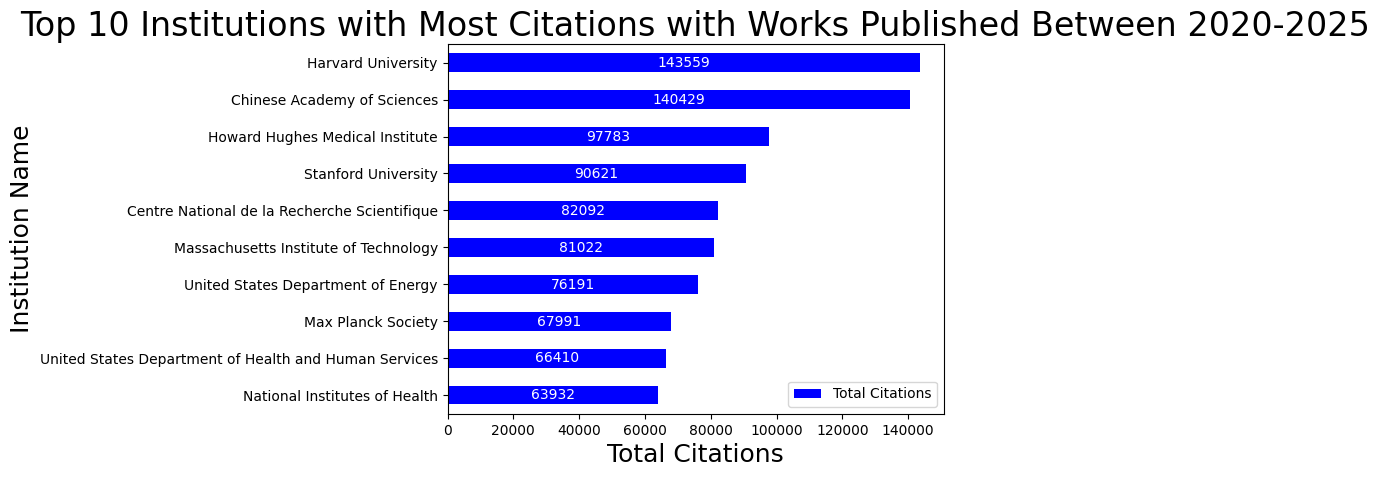

In [13]:
# Plot the top ten institutions with most citations across works published
# Dataframe is sorted, first 10 rows will have the most citations
ten_most_cited = total_citations.head(10).plot.barh(
    x='institution',
    y='total_citations',
    color='blue'
)

# Title and label the graph as approprite
ten_most_cited.set_title(label='Top 10 Institutions with Most Citations with Works Published Between 2020-2025', fontsize=24, color='black')
ten_most_cited.set_xlabel('Total Citations', fontsize=18, color='black')
ten_most_cited.set_ylabel('Institution Name', fontsize=18, color='black')
ten_most_cited.legend(['Total Citations'])

# Invert the y-axis to sort the bars in descending order
ten_most_cited.invert_yaxis()

# Annotate the bars
ten_most_cited.bar_label(ten_most_cited.containers[0], label_type='center', color='white')

These are the top ten institutions that have received the most citations across all works they published between the years 2020-2025. Visualizes the first ten rows total_citations table.

# Co-Authorship Patterns Among Institutions

## Mapping Institution IDs

In [14]:
# Map an institution ID to its name 
institution_map = (
    works_institutions_df
    .groupby('institution_id')['institution_name']
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

# Preview mapping entries
print(f"Institution map: {len(institution_map):,} entries")
print("\nSample entries:")
for aid, name in list(institution_map.items())[:5]:
    print(f"  {aid:>12} → {name}")

Institution map: 6,936 entries

Sample entries:
         52325 → Fundação Oswaldo Cruz
         80043 → Institut Curie
        189991 → University of Veterinary Medicine Hannover, Foundation
        241749 → University of Cambridge
        251738 → Edinburgh Napier University


## Building Transactions

In [15]:
# Group each work ID to a set of institution IDs
work_institutions = (
    works_institutions_df
    .groupby('work_id')['institution_id']
    .apply(set)
)

# Convert to a list of lists for mlxtend
transactions = [list(institutions) for institutions in work_institutions]

# Preview the first transaction
sample_work = work_institutions.index[0]
sample_ids = transactions[0]
sample_inst_names = [institution_map.get(a, 'Unknown') for a in sample_ids]
print(f"\nSample transaction (work_id={sample_work}):")
print(f"  institution_ids : {sample_ids}")
print(f"  names      : {sample_inst_names}")


Sample transaction (work_id=2737420523):
  institution_ids : [np.int64(5388228), np.int64(4210138311), np.int64(1302918504), np.int64(122411786), np.int64(198811213), np.int64(161318765), np.int64(84218800), np.int64(1282311441), np.int64(196817621), np.int64(1330989302), np.int64(4210113689), np.int64(39422238), np.int64(4210104735)]
  names      : ['University of Rochester', 'Lawrence Livermore National Security', 'Planetary Science Institute', 'California Institute of Technology', 'National Nuclear Security Administration', 'University of California, Los Angeles', 'University of California, Davis', 'Lawrence Livermore National Laboratory', 'Carnegie Institution for Science', 'United States Department of Energy', 'Energetics (United States)', 'University of Illinois Chicago', 'Sandia National Laboratories']


## Constructing TransactionEncoder (for Apriori)

In [16]:
# Converts the transaction matrix into a one-hot encoded dataframe
# Required input format for Apriori to run
te = TransactionEncoder()

# Use fit_transform to learn the full item univerise, then encode each transaction
te_array = te.fit_transform(transactions)

# Construct a dataframe from the encoded matrix where columns represent institution IDs
te_df = pd.DataFrame(te_array, columns=te.columns_)

# Display the dimensions of the te matrix
print(f"Encoded matrix shape: {te_df.shape}")
print(f"  {te_df.shape[0]:,} rows  (works / transactions)")
print(f"  {te_df.shape[1]:,} cols  (unique institutions / items)")

# Display the sparsity of the matrix
sparsity = (~te_df).sum().sum() / te_df.size
print(f"\nSparsity: {sparsity:.3%} of values are False")

te_df.head()

Encoded matrix shape: (9097, 6936)
  9,097 rows  (works / transactions)
  6,936 cols  (unique institutions / items)

Sparsity: 99.903% of values are False


,52325,80043,189991,241749,251738,308837,324100,352274,376102,392282,...,4402554182,4403386587,4403386645,4403386660,4403386689,4403386790,4403928284,4407990293,4407990318,4407990431
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
# Detect names shared by more than one institution ID
name_counts = pd.Series(institution_map.values()).value_counts()
duplicates = set(name_counts[name_counts > 1].index)

# Build display label to differentiate institutions that share the same name
# Will be plain if the name is unique, in the format "Name [id]" if shared
institution_display_map = {
    aid: (f"{name} [{aid}]" if name in duplicates else name)
    for aid, name in institution_map.items()
}

# Label the transaction encoder dataframe using the display map
labeled_te_df = te_df.rename(columns=institution_display_map)

labeled_te_df.head()

,Fundação Oswaldo Cruz,Institut Curie,"University of Veterinary Medicine Hannover, Foundation",University of Cambridge,Edinburgh Napier University,Suzhou University of Science and Technology,Bowie State University,Deccan College Post Graduate and Research Institute,Agricultural Research Organization,"University at Albany, State University of New York",...,IMRA America (United States),Structure fédérative de recherche Necker,Institut de recherche Saint-Louis,Liaoning Academy of Materials,Petrified Forest National Park,"National Center for Theoretical Sciences, Physics Division",Institut für Mikrobiologie der Bundeswehr,Université Marie et Louis Pasteur,Indiana University Columbus,Université Bourgogne Europe
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Apriori Search

In [18]:
# Testing five different min support thresholds: 
# institutions appearing in 0.3%, 0.5%, 1%, 2%, and 5% of papers respectively
min_supports = [0.003, 0.005, 0.01, 0.02, 0.05]
counts = []
for ms in min_supports:
    fi = apriori(labeled_te_df, min_support=ms, use_colnames=True, verbose=0)

    # Append the length of each set of frequent itemsets to the list counts
    counts.append(len(fi))

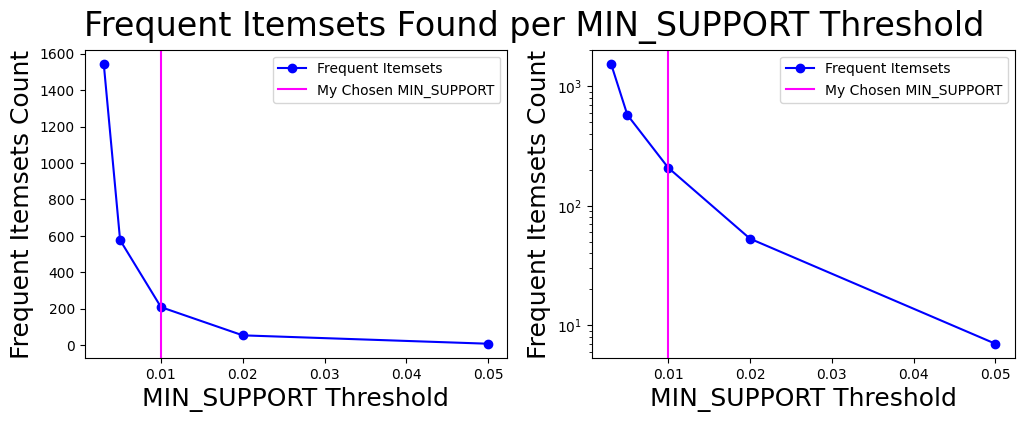

In [19]:
# Convert the array data obtained from the Apriori search to dataframes for plotting
minsup_df = pd.DataFrame(min_supports, columns=["MIN_SUPPORT"])
counts_df = pd.DataFrame(counts, columns=["Frequent Itemsets"])

# Construct a temporary dataframe combining the information for the minimum support
# and frequent itemsets counts to plot
minsup_to_itemsets = pd.concat([minsup_df, counts_df], axis=1)

# Construct two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Set a single title for both plots
fig.suptitle('Frequent Itemsets Found per MIN_SUPPORT Threshold', fontsize=24, color='black')

# Plot the combined dataframe on the left panel
ax1 = minsup_to_itemsets.plot(x='MIN_SUPPORT', y='Frequent Itemsets', ax=ax1, color='blue', marker='o')

# Label the axes as appropriate
ax1.set_xlabel('MIN_SUPPORT Threshold', fontsize=18, color='black')
ax1.set_ylabel('Frequent Itemsets Count', fontsize=18, color='black')

# Add a vertical line annotation on the left panel for my chosen MIN_SUPPORT threshold
# the "elbow" of the graph
ax1.axvline(x=0.01, color='magenta')

# Add a legend to the left panel to annotate the graph line and chosen MIN_SUPPORT threshold
ax1.legend(['Frequent Itemsets', 'My Chosen MIN_SUPPORT'])

# Plot the combined dataframe on the right panel
ax2 = minsup_to_itemsets.plot(x='MIN_SUPPORT', y='Frequent Itemsets', ax=ax2, color='blue', marker='o')

# Label the axes as appropriate
ax2.set_xlabel('MIN_SUPPORT Threshold', fontsize=18, color='black')
ax2.set_ylabel('Frequent Itemsets Count', fontsize=18, color='black')

# Convert the right panel to a logarithmic axis
ax2.set_yscale('log')

# Add a vertical line annotation on the right panel for my chosen MIN_SUPPORT threshold
ax2.axvline(x=0.01, color='magenta')

# Add a legend to the right panel to annotate the graph line and chosen MIN_SUPPORT threshold
ax2.legend(['Frequent Itemsets', 'My Chosen MIN_SUPPORT'])

Visualizes the total number of frequent itemsets plotted at each tested MIN_SUPPORT threshold. The vertical magenta line represents the MIN_SUPPORT threshold I chose for this analysis. My chosen MIN_SUPPORT threshold states that the authoring institution(s) appear in at least 1% of all papers within the dataset. This chosen MIN_SUPPORT threshold is intuitively significant and yields 208 frequent itemsets, which is roughly in the middle of the recommended 100-500 frequent itemsets.

In [20]:
# Institution pair appears in at least 1% of papers
MIN_SUPPORT = 0.01

# Run the Apriori search
print(f"Running Apriori at min_support threshold {MIN_SUPPORT}")
frequent_itemsets = apriori(
    labeled_te_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=None,
    verbose=1,
)

# Sort found frequent itemsets by support
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print(f"There are {len(frequent_itemsets):,} frequent itemsets at MIN_SUPPORT threshold {MIN_SUPPORT}")

frequent_itemsets.head()

Running Apriori at min_support threshold 0.01
Processing 75 combinations | Sampling itemset size 5432
There are 208 frequent itemsets at MIN_SUPPORT threshold 0.01


,support,itemsets
48,0.088820,frozenset({Harvard University})
3,0.071672,frozenset({Chinese Academy of Sciences})
79,0.068374,frozenset({Centre National de la Recherche Scientifique})
32,0.062768,frozenset({Stanford University})
53,0.061669,frozenset({Max Planck Society})


In [21]:
# Add itemset length column for easy filtering
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

# Display the proportion of frequent itemsets found for each size
print("Frequent itemsets found by size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

Frequent itemsets found by size:
length
1    108
2     64
3     27
4      8
5      1


In [22]:
print("Most frequent institutions publishing solo:")
freq_insts = (
    # Filter to find the most frequent 1-itemsets
    frequent_itemsets[frequent_itemsets['length'] == 1]
    .head(10)
    [['support', 'itemsets']]
)

display(freq_insts)

Most frequent institutions publishing solo:


,support,itemsets
48,0.088820,frozenset({Harvard University})
3,0.071672,frozenset({Chinese Academy of Sciences})
79,0.068374,frozenset({Centre National de la Recherche Scientifique})
32,0.062768,frozenset({Stanford University})
53,0.061669,frozenset({Max Planck Society})
87,0.059800,frozenset({Howard Hughes Medical Institute})
84,0.055623,frozenset({United States Department of Energy})
20,0.048917,frozenset({Massachusetts Institute of Technology})
11,0.045180,frozenset({Office of Science})
90,0.043751,frozenset({Board of the Swiss Federal Institutes of Technology})


[Text(0, 0, '0.0888205'),
 Text(0, 0, '0.071672'),
 Text(0, 0, '0.0683742'),
 Text(0, 0, '0.0627679'),
 Text(0, 0, '0.0616687'),
 Text(0, 0, '0.0597999'),
 Text(0, 0, '0.0556227'),
 Text(0, 0, '0.0489172'),
 Text(0, 0, '0.0451797'),
 Text(0, 0, '0.0437507')]

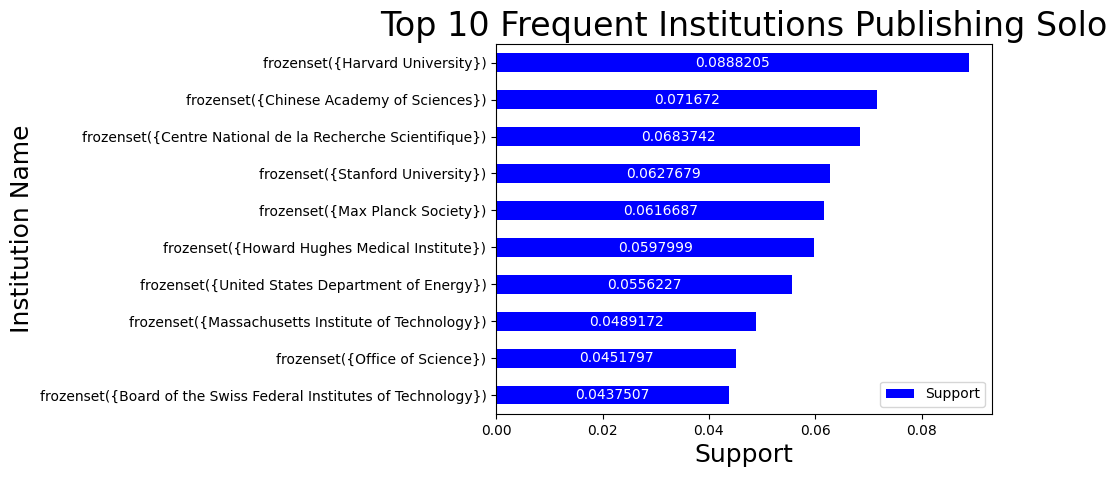

In [23]:
# Sort by support in descending order
freq_insts = freq_insts.sort_values(by='support', ascending=False)

# Plot the top ten pairs of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_freq_insts = freq_insts.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_freq_insts.set_title(label='Top 10 Frequent Institutions Publishing Solo', fontsize=24, color='black')
top_ten_freq_insts.set_xlabel('Support', fontsize=18, color='black')
top_ten_freq_insts.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_freq_insts.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_freq_insts.invert_yaxis()

# Annotate the bars
top_ten_freq_insts.bar_label(top_ten_freq_insts.containers[0], label_type='center', color='white')

These are the top ten institutions publishing solo that have the highest support (i.e. publish most frequently). There is a lot of overlap with the top ten most cited institutions chart.

# Which Pairs of Institutions Publish Most Frequently Together?

In [24]:
print("Most frequent PAIRS of institutions publishing together:")
freq_inst_pairs = (
    # Filter to find the most frequent 2-itemsets
    frequent_itemsets[frequent_itemsets['length'] == 2]
    .head(10)
    [['support', 'itemsets']]
)

display(freq_inst_pairs)

Most frequent PAIRS of institutions publishing together:


,support,itemsets
122,0.045180,"frozenset({Office of Science, United States Department of Energy})"
164,0.029240,"frozenset({United States Department of Health and Human Services, National I..."
129,0.028141,"frozenset({Harvard University, Mass General Brigham})"
127,0.024514,"frozenset({University College London, University of London})"
116,0.024184,"frozenset({ETH Zurich, Board of the Swiss Federal Institutes of Technology})"
135,0.023304,"frozenset({UK Research and Innovation, Medical Research Council})"
131,0.023194,"frozenset({Massachusetts General Hospital, Mass General Brigham})"
114,0.021875,"frozenset({Chinese Academy of Sciences, University of Chinese Academy of Sci..."
120,0.020996,"frozenset({Lawrence Berkeley National Laboratory, Office of Science})"
148,0.020996,"frozenset({Lawrence Berkeley National Laboratory, United States Department o..."


[Text(0, 0, '0.0451797'),
 Text(0, 0, '0.0292404'),
 Text(0, 0, '0.0281411'),
 Text(0, 0, '0.0245136'),
 Text(0, 0, '0.0241838'),
 Text(0, 0, '0.0233044'),
 Text(0, 0, '0.0231945'),
 Text(0, 0, '0.0218753'),
 Text(0, 0, '0.0209959'),
 Text(0, 0, '0.0209959')]

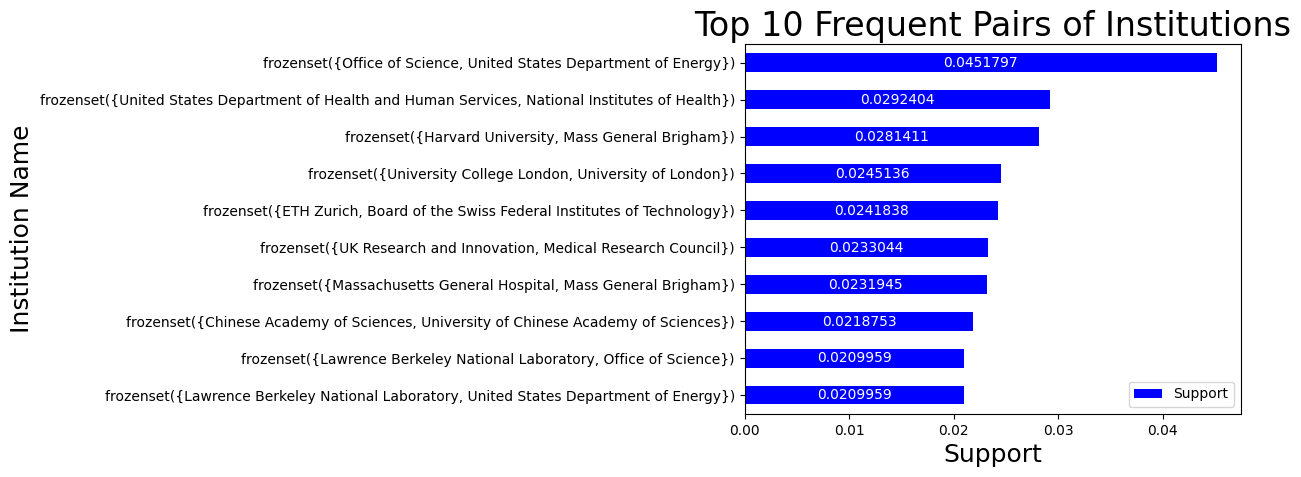

In [25]:
# Sort by support in descending order
freq_inst_pairs = freq_inst_pairs.sort_values(by='support', ascending=False)

# Plot the top ten pairs of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_pairs = freq_inst_pairs.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_pairs.set_title(label='Top 10 Frequent Pairs of Institutions', fontsize=24, color='black')
top_ten_pairs.set_xlabel('Support', fontsize=18, color='black')
top_ten_pairs.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_pairs.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_pairs.invert_yaxis()

# Annotate the bars
top_ten_pairs.bar_label(top_ten_pairs.containers[0], label_type='center', color='white')

These are the top ten institutions publishing together IN GROUPS OF TWO that have the highest support (i.e. publish most frequently). Interestingly, there is a lot less overlap with the top ten most cited institutions compared to the most frequent solo institutions, which suggests a lot of these highly cited institutions act independently. Additionally, there appears to not be a lot of collaboration between the top ten most cited institutions. A lot of these institutions either collaborate within their own ecosystems or with federal institutions.

# What about Groups Larger than Two?

In [26]:
print("Most frequent GROUPS (larger than two) of institutions publishing together:")
freq_inst_groups = (
    # Filter to find the most frequent n-itemsets where n > 2
    frequent_itemsets[frequent_itemsets['length'] > 2]
    .head(10)
    [['support', 'itemsets']]
)

display(freq_inst_groups)

Most frequent GROUPS (larger than two) of institutions publishing together:


,support,itemsets
179,0.020996,"frozenset({Lawrence Berkeley National Laboratory, Office of Science, United ..."
185,0.020226,"frozenset({Massachusetts General Hospital, Harvard University, Mass General ..."
176,0.014290,"frozenset({Office of Science, University of California, Berkeley, United Sta..."
187,0.013411,"frozenset({Lawrence Berkeley National Laboratory, University of California, ..."
200,0.013411,"frozenset({Lawrence Berkeley National Laboratory, Office of Science, Univers..."
175,0.013411,"frozenset({Lawrence Berkeley National Laboratory, Office of Science, Univers..."
177,0.013191,"frozenset({Stanford University, Office of Science, United States Department ..."
184,0.012312,"frozenset({Harvard University, Mass General Brigham, Brigham and Women's Hos..."
206,0.011542,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè..."
195,0.011542,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè..."


[Text(0, 0, '0.0209959'),
 Text(0, 0, '0.0202264'),
 Text(0, 0, '0.0142904'),
 Text(0, 0, '0.013411'),
 Text(0, 0, '0.013411'),
 Text(0, 0, '0.013411'),
 Text(0, 0, '0.0131912'),
 Text(0, 0, '0.0123118'),
 Text(0, 0, '0.0115423'),
 Text(0, 0, '0.0115423')]

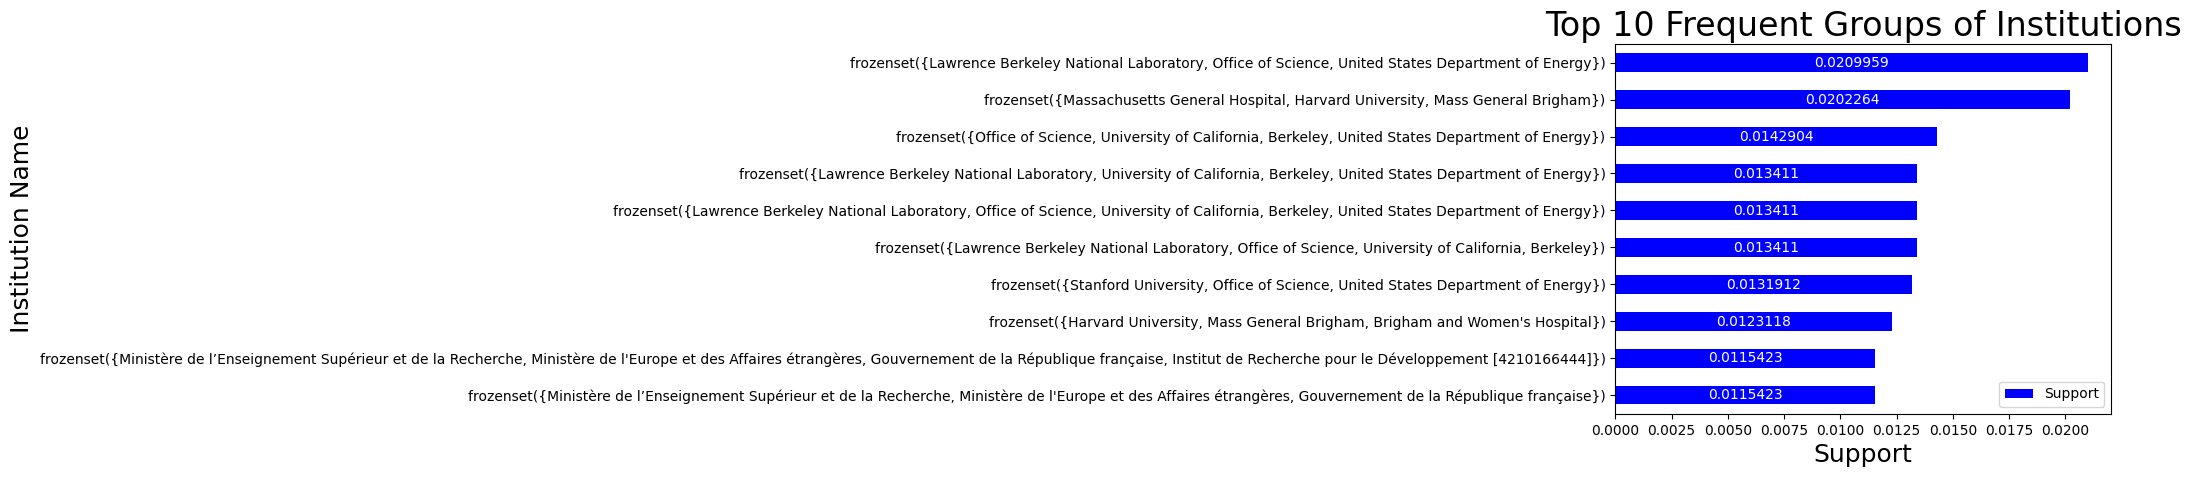

In [27]:
# Sort by support in descending order
freq_inst_groups = freq_inst_groups.sort_values(by='support', ascending=False)

# Plot the top ten groups of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_groups = freq_inst_groups.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_groups.set_title(label='Top 10 Frequent Groups of Institutions', fontsize=24, color='black')
top_ten_groups.set_xlabel('Support', fontsize=18, color='black')
top_ten_groups.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_groups.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_groups.invert_yaxis()

# Annotate the bars
top_ten_groups.bar_label(top_ten_groups.containers[0], label_type='center', color='white')

These are the top ten institutions publishing together IN GROUPS OF LARGER THAN TWO that have the highest support (i.e. publish most frequently). Similar to the most frequent pairs, there appears to not be a lot of collaboration between the top ten most cited institutions. A lot of these institutions either collaborate within their own ecosystems or with federal institutions.

## Generating Association Rules

In [28]:
# Generate rules using Kulczynski, a symmetric measure.
rules_df = association_rules(
    frequent_itemsets,
    metric='kulczynski',
    min_threshold=0.5,
    num_itemsets=len(frequent_itemsets),
)

print(f"Generated {len(rules_df):,} association rules")
rules_df.sort_values(by='kulczynski', ascending=False).head(10)

Generated 374 association rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
127,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
122,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
104,"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
96,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
101,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...","frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
100,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...","frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
144,frozenset({Icahn School of Medicine at Mount Sinai}),frozenset({Mount Sinai Health System}),0.011432,0.011432,0.011432,1.0,87.471154,1.0,0.011302,inf,1.0,1.0,1.0,1.0
133,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
109,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0
105,"frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",0.011542,0.011542,0.011542,1.0,86.638095,1.0,0.011409,inf,1.0,1.0,1.0,1.0


I chose Kulczynski as my primary means of assessing rules becaude direction does not matter here. For example, if Harvard and Yale wrote a paper together it does not matter which one comes first as they are both associated with the work.

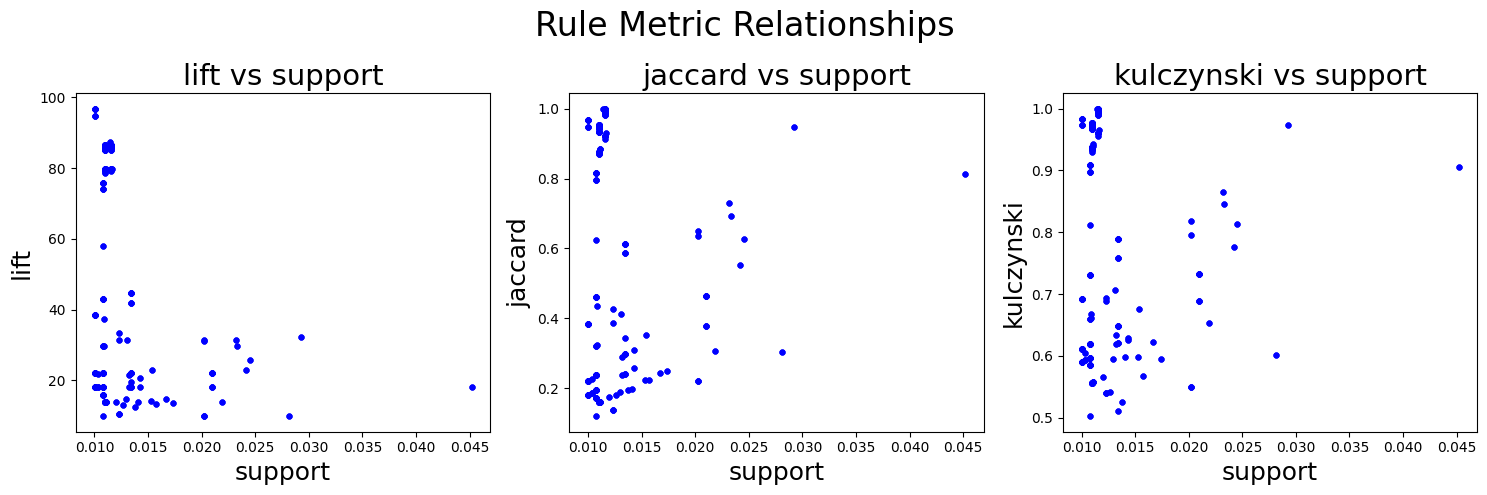

In [29]:
# Construct a 3-panel scatterplot comparing lift, jaccard, and kulczynski measures
# of the generated rule metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Construct a scatter plot for each metric, adjusted transparency, size, and color for readability
for ax, y_metric in zip(axes, ['lift', 'jaccard', 'kulczynski']):
    ax.scatter(rules_df['support'], rules_df[y_metric],
               alpha=1, s=12, color='blue')
    ax.set_xlabel('support', fontsize=18, color='black')
    ax.set_ylabel(y_metric, fontsize=18, color='black')
    ax.set_title(f'{y_metric} vs support', fontsize=21, color='black')

plt.suptitle("Rule Metric Relationships", fontsize=24, color='black')
plt.tight_layout()
plt.show()

Plots the relationships between rule metrics against support. I chose Jaccard and Kulczynski as my primary means of evaluation as they are null-invariant and symmetric. As mentioned above, direction does not matter here but symmetry does. Use lift as a sanity check to help measure the strength of the correlation. Lower support values are associated with higher lift values whereas Jaccard and Kulczynski values are more evenly dispersed.

# Helper Functions for Rule Mining

In [30]:
def rules_involving(rules_df, label, side='either'):
    """
    Filter rules that involve a specific author display label.

    Parameters
    ----------
    rules_df : association rules DataFrame
    label    : str — the author display label (from author_display_map)
    side     : 'antecedent' | 'consequent' | 'either'
    """
    in_ant = rules_df['antecedents'].apply(lambda x: label in x)
    in_con = rules_df['consequents'].apply(lambda x: label in x)

    if side == 'antecedent':
        mask = in_ant
    elif side == 'consequent':
        mask = in_con
    else:
        mask = in_ant | in_con

    return rules_df[mask].sort_values('lift', ascending=False)


def rules_with_antecedent_size(rules_df, size):
    """Filter rules where the antecedent has exactly `size` items."""
    return rules_df[rules_df['antecedents'].apply(len) == size]

# Recycled from rules_with_antecedent_size to help with one of my searches
def rules_with_min_antecedent_size(rules_df, size):
    """Filter rules where the antecedent has at least `size` items."""
    return rules_df[rules_df['antecedents'].apply(len) >= size]


def rules_above_thresholds(rules_df, min_confidence=0.5, min_lift=2.0):
    """Filter rules meeting both confidence and lift thresholds."""
    return rules_df[
        (rules_df['confidence'] >= min_confidence) &
        (rules_df['lift']       >= min_lift)
    ]


def fmt_set(s):
    """Render a frozenset of author labels as a readable string."""
    return ', '.join(sorted(str(x) for x in s))

print("Helper functions defined ✅")

Helper functions defined ✅


# Filtering Rules for Institution Combinations

In [31]:
# Rules with a single-instutution antecedent and single-institution consequent
inst_1_to_1_rules = (
    rules_with_antecedent_size(rules_df, 1)
    .pipe(lambda df: df[df['consequents'].apply(len) == 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"1-institution antecedent → 1-institution consequent: {len(inst_1_to_1_rules)} rules")
inst_1_to_1_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

1-institution antecedent → 1-institution consequent: 90 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
145,frozenset({Mount Sinai Health System}),frozenset({Icahn School of Medicine at Mount Sinai}),0.011432,1.000000,87.471154,1.000000,1.000000
144,frozenset({Icahn School of Medicine at Mount Sinai}),frozenset({Mount Sinai Health System}),0.011432,1.000000,87.471154,1.000000,1.000000
120,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,0.990566,85.820755,0.990566,0.995283
121,frozenset({Institut de Recherche pour le Développement [4210166444]}),frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.011542,1.000000,85.820755,0.990566,0.995283
143,frozenset({Ministère de l'Europe et des Affaires étrangères}),frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,0.990566,85.820755,0.990566,0.995283
142,frozenset({Institut de Recherche pour le Développement [4210166444]}),frozenset({Ministère de l'Europe et des Affaires étrangères}),0.011542,1.000000,85.820755,0.990566,0.995283
111,frozenset({Ministère de l'Europe et des Affaires étrangères}),frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.011542,0.990566,85.011125,0.981308,0.990566
110,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),frozenset({Ministère de l'Europe et des Affaires étrangères}),0.011542,0.990566,85.011125,0.981308,0.990566
3,frozenset({National Institutes of Health}),frozenset({United States Department of Health and Human Services}),0.029240,1.000000,32.373665,0.946619,0.973310
2,frozenset({United States Department of Health and Human Services}),frozenset({National Institutes of Health}),0.029240,0.946619,32.373665,0.946619,0.973310


In [32]:
# Rules with a single-instutution antecedent and n-institution consequent
inst_1_to_n_rules = (
    rules_with_antecedent_size(rules_df, 1)
    .pipe(lambda df: df[df['consequents'].apply(len) > 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"1-institution antecedent → n-institution consequent: {len(inst_1_to_n_rules)} rules")
inst_1_to_n_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

1-institution antecedent → n-institution consequent: 108 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
127,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",0.011542,1.000000,86.638095,1.000000,1.000000
133,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",0.011542,1.000000,86.638095,1.000000,1.000000
109,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",0.011542,1.000000,86.638095,1.000000,1.000000
118,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",0.011542,0.990566,85.820755,0.990566,0.995283
107,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",0.011542,0.990566,85.820755,0.990566,0.995283
106,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...",0.011542,0.990566,85.820755,0.990566,0.995283
131,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),"frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...",0.011542,0.990566,85.820755,0.990566,0.995283
125,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...",0.011542,0.990566,85.820755,0.990566,0.995283
138,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...",0.011542,0.990566,85.820755,0.990566,0.995283
137,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l'Europe et des Affaires étrangères, Gouvernement de...",0.011542,1.000000,85.820755,0.990566,0.995283


In [33]:
# Rules with an n-instutution antecedent and single-institution consequent
inst_n_to_1_rules = (

    # See helper functions
    rules_with_min_antecedent_size(rules_df, 2)
    .pipe(lambda df: df[df['consequents'].apply(len) == 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"n-institution antecedent → 1-institution consequent: {len(inst_n_to_1_rules)} rules")
inst_n_to_1_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

n-institution antecedent → 1-institution consequent: 108 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
96,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,1.000000,86.638095,1.000000,1.000000
128,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,1.000000,86.638095,1.000000,1.000000
122,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,1.000000,86.638095,1.000000,1.000000
98,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.011542,1.000000,85.820755,0.990566,0.995283
99,"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...",frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.011542,1.000000,85.820755,0.990566,0.995283
123,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.011542,1.000000,85.820755,0.990566,0.995283
124,"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...",frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.011542,1.000000,85.820755,0.990566,0.995283
115,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.011542,1.000000,85.820755,0.990566,0.995283
136,"frozenset({Ministère de l'Europe et des Affaires étrangères, Gouvernement de...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.011542,0.990566,85.820755,0.990566,0.995283
135,"frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.011542,1.000000,85.820755,0.990566,0.995283


In [34]:
# Rules with a n-instutution antecedent and n-institution consequent
inst_m_to_n_rules = (

    # See helper functions
    rules_with_min_antecedent_size(rules_df, 2)
    .pipe(lambda df: df[df['consequents'].apply(len) > 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"m-institution antecedent → n-institution consequent: {len(inst_m_to_n_rules)} rules")
inst_m_to_n_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

m-institution antecedent → n-institution consequent: 68 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
105,"frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...",0.011542,1.000000,86.638095,1.000000,1.000000
104,"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...",0.011542,1.000000,86.638095,1.000000,1.000000
100,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Ministè...","frozenset({Institut de Recherche pour le Développement [4210166444], Gouvern...",0.011542,1.000000,86.638095,1.000000,1.000000
101,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...","frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...",0.011542,1.000000,86.638095,1.000000,1.000000
103,"frozenset({Ministère de l'Europe et des Affaires étrangères, Gouvernement de...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...",0.011542,0.990566,85.820755,0.990566,0.995283
102,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...","frozenset({Ministère de l'Europe et des Affaires étrangères, Gouvernement de...",0.011542,1.000000,85.820755,0.990566,0.995283
369,"frozenset({United States Department of Energy, Argonne National Laboratory})","frozenset({Office of Science, University of Chicago})",0.010003,1.000000,96.776596,0.968085,0.984043
364,"frozenset({Office of Science, University of Chicago})","frozenset({United States Department of Energy, Argonne National Laboratory})",0.010003,0.968085,96.776596,0.968085,0.984043
217,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Gouvern...","frozenset({Centre National de la Recherche Scientifique, Ministère de l'Euro...",0.010993,0.952381,86.638095,0.952381,0.976190
216,"frozenset({Institut de Recherche pour le Développement [4210166444], Ministè...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Centre ...",0.010993,0.952381,86.638095,0.952381,0.976190
